In [53]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler 

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 

from sklearn.linear_model import LogisticRegression


### 1. Data Loading and Initial Exploration 


In [54]:
df = pd.read_csv('titanic_data_updated (1).csv') 

df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
374,375,no,third,"Palsson, Miss. Stina Viola",female,3.0,3,1,349909,21.0750,NaN,S
173,174,no,third,"Sivola, Mr. Antti Wilhelm",male,21.0,0,0,STON/O 2. 3101280,7.9250,NaN,S
859,860,no,third,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
682,683,no,third,"Olsvigen, Mr. Thor Anderson",male,20.0,0,0,6563,9.2250,NaN,S
342,343,no,second,"Collander, Mr. Erik Gustaf",male,28.0,0,0,248740,13.0000,NaN,S


In [55]:
df['Cabin'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Cabin
Non-Null Count  Dtype 
--------------  ----- 
204 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


### Feature Engineering 

In [56]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1 
df['Cabin'] = df['Cabin'].fillna("Missing") 

df['Deck'] = df['Cabin'].astype(str).str[0] 
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Family_Size,Deck
497,no,third,male,NaN,0,0,15.10,Missing,S,1,M
439,no,second,male,31.0,0,0,10.50,Missing,S,1,M
201,no,third,male,NaN,8,2,69.55,Missing,S,11,M
525,no,third,male,40.5,0,0,7.75,Missing,Q,1,M
545,no,first,male,64.0,0,0,26.00,Missing,S,1,M


In [57]:
df['Deck'].value_counts()

Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [58]:
X = df.drop('Survived', axis =1) 
y = df['Survived']

In [59]:
y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [60]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42, stratify=y)

In [61]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Family_Size,Deck
692,third,male,NaN,0,0,56.4958,Missing,S,1,M
481,second,male,NaN,0,0,0.0000,Missing,S,1,M
527,first,male,NaN,0,0,221.7792,C95,S,1,C
855,third,female,18.0,0,1,9.3500,Missing,S,2,M
801,second,female,31.0,1,1,26.2500,Missing,S,3,M
...,...,...,...,...,...,...,...,...,...,...
359,third,female,NaN,0,0,7.8792,Missing,Q,1,M
258,first,female,35.0,0,0,512.3292,Missing,C,1,M
736,third,female,48.0,1,3,34.3750,Missing,S,5,M
462,first,male,47.0,0,0,38.5000,E63,S,1,E


<Axes: xlabel='Survived', ylabel='count'>

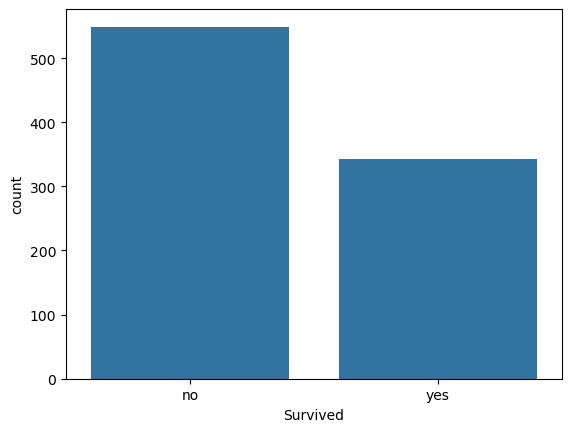

In [62]:
sns.countplot(data=df, x=df['Survived'])

### ML Pipeline

In [63]:
# imputer_transformers = ColumnTransformer(
#     transformers=[
#         ('age',SimpleImputer(missing_values=np.nan,strategy='mean'),['Age']),
#         ('emabarked',SimpleImputer(missing_values=np.nan, strategy='most_frequent'),['Embarked']),
#         ('cabin',SimpleImputer(missing_values=np.nan, strategy='constant',fill_value='Missing', add_indicator=True),['Cabin'])
#     ],
#     remainder='passthrough',
#     verbose_feature_names_out=False
    
# )

# imputer_transformers.set_output(transform='pandas')
# imputer_transformers.fit(X_train)
# X_train = imputer_transformers.transform(X_train) 
# X_test = imputer_transformers.transform(X_test)

In [64]:
# Numerical values 

p1 = Pipeline(
    steps=[
        ('Imputer', SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())
    ]
)

p2 = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',MinMaxScaler())
        
    ]
)


In [65]:
categories=[['third','second','first']]

In [66]:
# Categorical values 

p3 = Pipeline(
    steps=[
        ('Imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(sparse_output=False,drop='first'))
    ]
)

p4 = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=categories,handle_unknown='ignore')),
        ('scaler',MinMaxScaler())
        
    ]
)
p4

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(categories=[['third', 'second', 'first']],
                                handle_unknown='ignore')),
                ('scaler', MinMaxScaler())])

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_1',p1,['Age']),
        ('pipeline_2',p2,['Fare','Family_size']),
        ('pipeline_3',p3,['Sex','Embarked','Deck']),
        ('pipeline_4',p4,['Pclass'])  
    ],
    remainder='drop'
)

In [68]:
preprocessor

ColumnTransformer(transformers=[('pipeline_1',
                                 Pipeline(steps=[('Imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Age']),
                                ('pipeline_2',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', MinMaxScaler())]),
                                 ['Fare', 'Family_size']),
                                ('pipeline_3',
                                 Pipeline(steps=[('Imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False))]),
                                 ['Sex', 'Embarked', 'Deck']),
                                ('pipeline_4',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['third',
                                                                              'second',
                                                                              'first']],
                                                                 handle_unknown='ignore')),
                                                 ('scaler', MinMaxScaler())]),
                                 ['Pclass'])])

### Moddel training

In [69]:
from sklearn.linear_model import LogisticRegression

In [75]:
lr_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model',LogisticRegression(class_weight='balanced',max_iter=10))
    ]
)
lr_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('pipeline_1',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age']),
                                                 ('pipeline_2',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Fare', 'Family_size']),
                                                 ('pipeline_3',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strateg...
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked', 'Deck']),
                                                 ('pipeline_4',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['third',
                                                                                               'second',
                                                                                               'first']],
                                                                                  handle_unknown='ignore')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Pclass'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=10))])